<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/03-operational-risk/operational_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

한글 폰트 설정.

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # 결과 재현을 위한 시드 고정

n_years = 10
annual_freq_lambda = 25  # 연평균 손실 발생 건수 (포아송 분포 모수)

loss_records = []
for year in range(2016, 2016 + n_years):
    n_events = np.random.poisson(annual_freq_lambda)  # 해당 연도 손실 발생 건수
    severities = np.random.lognormal(mean=8.5, sigma=1.8, size=n_events)  # 손실 심도(금액)
    for amount in severities:
        loss_records.append({'year': year, 'loss_amount': amount})

df_loss = pd.DataFrame(loss_records)
print(f"총 {n_years}년간 손실 건수: {len(df_loss)}건")
df_loss.head()

총 10년간 손실 건수: 256건


,year,loss_amount
0,2016,15769.600845
1,2016,76225.683717
2,2016,3224.470164
3,2016,3224.565455
4,2016,84337.599769


포아송 분포로 "1년에 손실이 몇 건 발생하는지"(빈도)를, 로그정규분포로 "각 손실 사건마다 손실액이 얼마인지"(심도)를 생성. 이 두 분포 조합이 바로 운영리스크 손실분포접근법(LDA)의 표준 모델링 방식. 실제 은행 데이터도 이런 형태(빈도는 포아송류, 심도는 로그정규/파레토류)를 띠는 경우가 많음.

연평균 손실 건수: 25.6건
전체 손실 총액: 10,339,593
평균 손실액: 40,389
최대 손실액: 5,050,090


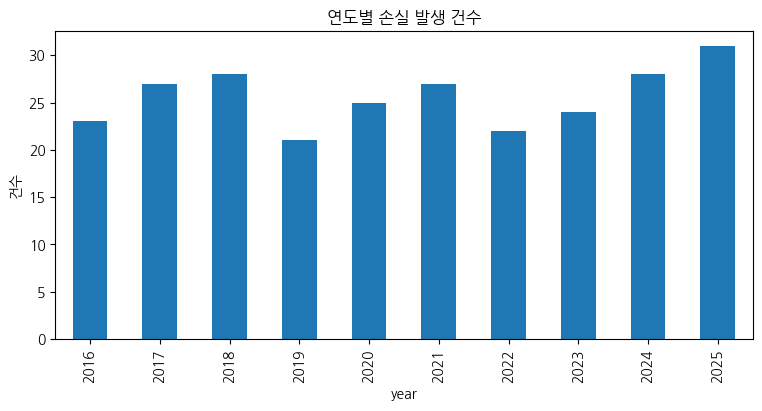

In [ ]:
print(f"연평균 손실 건수: {df_loss.groupby('year').size().mean():.1f}건")
print(f"전체 손실 총액: {df_loss['loss_amount'].sum():,.0f}")
print(f"평균 손실액: {df_loss['loss_amount'].mean():,.0f}")
print(f"최대 손실액: {df_loss['loss_amount'].max():,.0f}")

df_loss.groupby('year').size().plot(kind='bar', title='연도별 손실 발생 건수', figsize=(9,4))
plt.ylabel('건수')
plt.show()

연도별로 손실이 몇 건씩 발생했는지 막대그래프로 표현. 포아송 분포 특성상 연도마다 건수가 들쭉날쭉하지만 평균은 25건 근처로 수렴하게 됨.

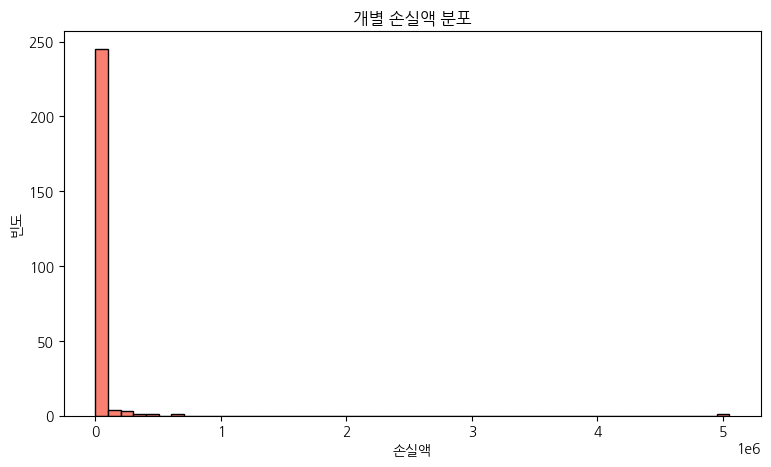

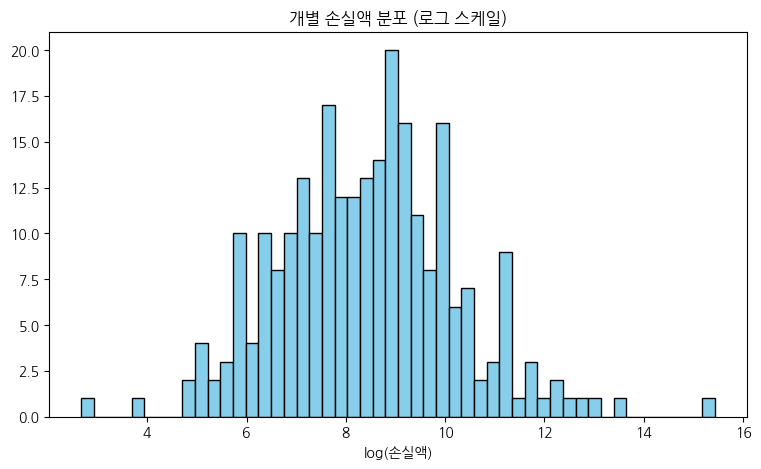

In [ ]:
plt.figure(figsize=(9,5))
plt.hist(df_loss['loss_amount'], bins=50, color='salmon', edgecolor='black')
plt.title('개별 손실액 분포')
plt.xlabel('손실액')
plt.ylabel('빈도')
plt.show()

plt.figure(figsize=(9,5))
plt.hist(np.log(df_loss['loss_amount']), bins=50, color='skyblue', edgecolor='black')
plt.title('개별 손실액 분포 (로그 스케일)')
plt.xlabel('log(손실액)')
plt.show()

운영리스크 손실은 보통 "대부분은 소액이지만 가끔 아주 큰 금액이 튀는" 형태. 첫 그래프에서 오른쪽으로 길게 꼬리가 늘어진 모양이 그 형태를 보여줌. 두 번째 그래프(로그 변환)는 그 분포가 로그정규분포에 가까운지 눈으로 확인하는 용도 — 종 모양(정규분포)에 가깝게 나오면 로그정규분포 가정이 타당하다는 뜻.

In [ ]:
from scipy import stats

log_losses = np.log(df_loss['loss_amount'])
mu, sigma = log_losses.mean(), log_losses.std()

print(f"로그정규분포 추정 모수: mu={mu:.3f}, sigma={sigma:.3f}")
print(f"\n손실액 분위수:")
print(f"50% (중앙값): {df_loss['loss_amount'].median():,.0f}")
print(f"95%: {df_loss['loss_amount'].quantile(0.95):,.0f}")
print(f"99%: {df_loss['loss_amount'].quantile(0.99):,.0f}")

로그정규분포 추정 모수: mu=8.427, sigma=1.806

손실액 분위수:
50% (중앙값): 4,741
95%: 82,700
99%: 360,643


실제 데이터로부터 로그정규분포의 모수(mu, sigma)를 추정. 이 값이 다음 단계인 몬테카를로 시뮬레이션에 그대로 쓰이게 됨.

In [ ]:
n_simulations = 10000
annual_total_losses = []

for _ in range(n_simulations):
    n_events_sim = np.random.poisson(annual_freq_lambda)  # 시뮬레이션된 연간 손실 건수
    if n_events_sim > 0:
        severities_sim = np.random.lognormal(mean=mu, sigma=sigma, size=n_events_sim)
        annual_total_losses.append(severities_sim.sum())
    else:
        annual_total_losses.append(0)

annual_total_losses = np.array(annual_total_losses)
print(f"시뮬레이션 완료: {n_simulations:,}개의 가상 연도 생성")
print(f"연간 총 손실 평균: {annual_total_losses.mean():,.0f}")
print(f"연간 총 손실 중앙값: {np.median(annual_total_losses):,.0f}")

시뮬레이션 완료: 10,000개의 가상 연도 생성
연간 총 손실 평균: 574,250
연간 총 손실 중앙값: 449,967


앞서 추정한 mu, sigma를 그대로 써서, "만약 내년이 10,000번 반복된다면 각각 얼마의 총 손실이 날까"를 가상으로 생성. 실제 데이터는 10년치뿐이지만, 이 시뮬레이션으로 10,000년치 시나리오를 확보.

In [ ]:
capital_99_9 = np.percentile(annual_total_losses, 99.9)
capital_99 = np.percentile(annual_total_losses, 99)
capital_95 = np.percentile(annual_total_losses, 95)

print(f"95% 신뢰수준 연간 손실: {capital_95:,.0f}")
print(f"99% 신뢰수준 연간 손실: {capital_99:,.0f}")
print(f"99.9% 신뢰수준 연간 손실 (= 운영리스크 소요자본): {capital_99_9:,.0f}")

95% 신뢰수준 연간 손실: 1,335,634
99% 신뢰수준 연간 손실: 2,462,059
99.9% 신뢰수준 연간 손실 (= 운영리스크 소요자본): 4,861,821


바젤 프레임워크에서 운영리스크 자기자본은 관례적으로 99.9% 신뢰수준의 연간 손실액으로 산출. "1,000년에 한 번 발생할 수준의 최악의 해에도 버틸 수 있는 자본"이라는 의미. 시장리스크의 VaR 95%/99%보다 훨씬 보수적인 신뢰수준을 쓰는 게 특징.

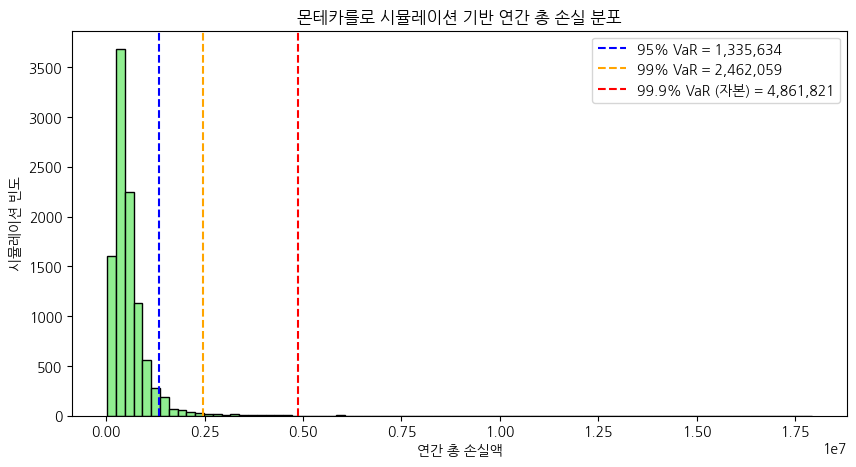

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(annual_total_losses, bins=80, color='lightgreen', edgecolor='black')
plt.axvline(capital_95, color='blue', linestyle='--', label=f'95% VaR = {capital_95:,.0f}')
plt.axvline(capital_99, color='orange', linestyle='--', label=f'99% VaR = {capital_99:,.0f}')
plt.axvline(capital_99_9, color='red', linestyle='--', label=f'99.9% VaR (자본) = {capital_99_9:,.0f}')
plt.title('몬테카를로 시뮬레이션 기반 연간 총 손실 분포')
plt.xlabel('연간 총 손실액')
plt.ylabel('시뮬레이션 빈도')
plt.legend()
plt.show()

10,000개 가상 연도의 총 손실액이 어떤 모양으로 분포하는지, 그리고 95%/99%/99.9% 기준선이 어디쯤 위치하는지 한눈에 보여줌.

BIA 기준 자기자본: 1,285,000
LDA(몬테카를로 99.9% VaR) 기준 자기자본: 4,861,821

차이: 3,576,821 (+278.4%)


Text(0, 0.5, '자기자본 소요액')

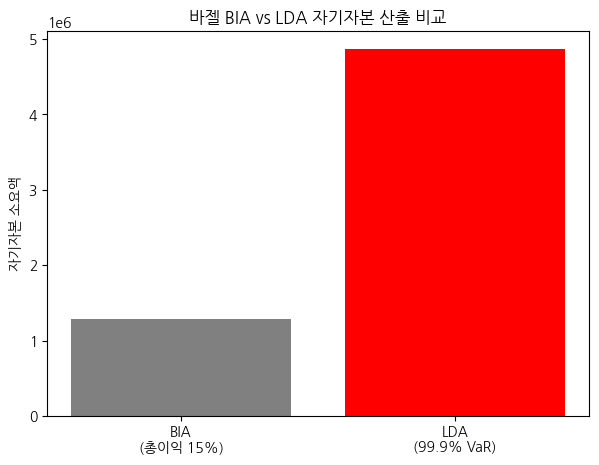

In [ ]:
# BIA는 최근 3년 평균 총이익(Gross Income)의 15%를 자기자본으로 산출
gross_income_estimates = [8_000_000, 8_500_000, 9_200_000]  # 가상의 최근 3년 총이익
alpha = 0.15

bia_capital = np.mean(gross_income_estimates) * alpha

print(f"BIA 기준 자기자본: {bia_capital:,.0f}")
print(f"LDA(몬테카를로 99.9% VaR) 기준 자기자본: {capital_99_9:,.0f}")
print(f"\n차이: {abs(bia_capital - capital_99_9):,.0f} ({(capital_99_9/bia_capital - 1)*100:+.1f}%)")

plt.figure(figsize=(7,5))
plt.bar(['BIA\n(총이익 15%)', 'LDA\n(99.9% VaR)'], [bia_capital, capital_99_9], color=['gray', 'red'])
plt.title('바젤 BIA vs LDA 자기자본 산출 비교')
plt.ylabel('자기자본 소요액')

BIA는 손실 데이터를 전혀 안 쓰고 오직 "은행 규모(총이익)"만으로 자본을 정하는 아주 단순한 방식. 반면 LDA는 실제 손실 패턴을 반영하기 때문에, 두 값이 얼마나 다른지 비교하면 "이 은행의 실제 리스크 프로파일이 규모 대비 과소/과대평가되고 있는지"를 판단할 수 있음.

In [ ]:
np.random.seed(7)
months = pd.date_range('2025-01-01', periods=24, freq='MS')

kri_data = pd.DataFrame({
    'month': months,
    '시스템_다운타임_시간': np.random.gamma(shape=2, scale=1.5, size=24),
    '직원_이직률(%)': np.random.normal(loc=5, scale=1.5, size=24).clip(0),
    '고객불만_건수': np.random.poisson(lam=12, size=24),
})

# 마지막 3개월에 의도적으로 위험 신호(악화 추세) 반영
kri_data.loc[21:, '시스템_다운타임_시간'] *= 2.5
kri_data.loc[21:, '고객불만_건수'] += 15

kri_data.head()

,month,시스템_다운타임_시간,직원_이직률(%),고객불만_건수
0,2025-01-01,1.701912,4.213093,19
1,2025-02-01,1.262327,5.249602,17
2,2025-03-01,2.504002,5.107498,12
3,2025-04-01,5.033853,4.481424,14
4,2025-05-01,3.852478,5.212264,14


실제 운영리스크 관리에서 자주 쓰이는 3가지 KRI를 예시로 생성 : 시스템 다운타임(IT 리스크), 직원 이직률(인력 리스크), 고객불만 건수(프로세스/평판 리스크). 마지막 3개월은 일부러 악화되는 추세를 넣어서, 임계치 초과 상황을 시뮬레이션.

In [ ]:
thresholds = {
    '시스템_다운타임_시간': 5.0,
    '직원_이직률(%)': 8.0,
    '고객불만_건수': 20
}

for kri, limit in thresholds.items():
    breach_count = (kri_data[kri] > limit).sum()
    print(f"[{kri}] 임계치 {limit} 초과 월: {breach_count}회 / 24개월")

[시스템_다운타임_시간] 임계치 5.0 초과 월: 5회 / 24개월
[직원_이직률(%)] 임계치 8.0 초과 월: 0회 / 24개월
[고객불만_건수] 임계치 20 초과 월: 2회 / 24개월


각 KRI마다 "이 수준을 넘으면 위험 신호"로 볼 임계치를 정하고, 지난 24개월 중 몇 번이나 이 기준을 넘었는지 파악.

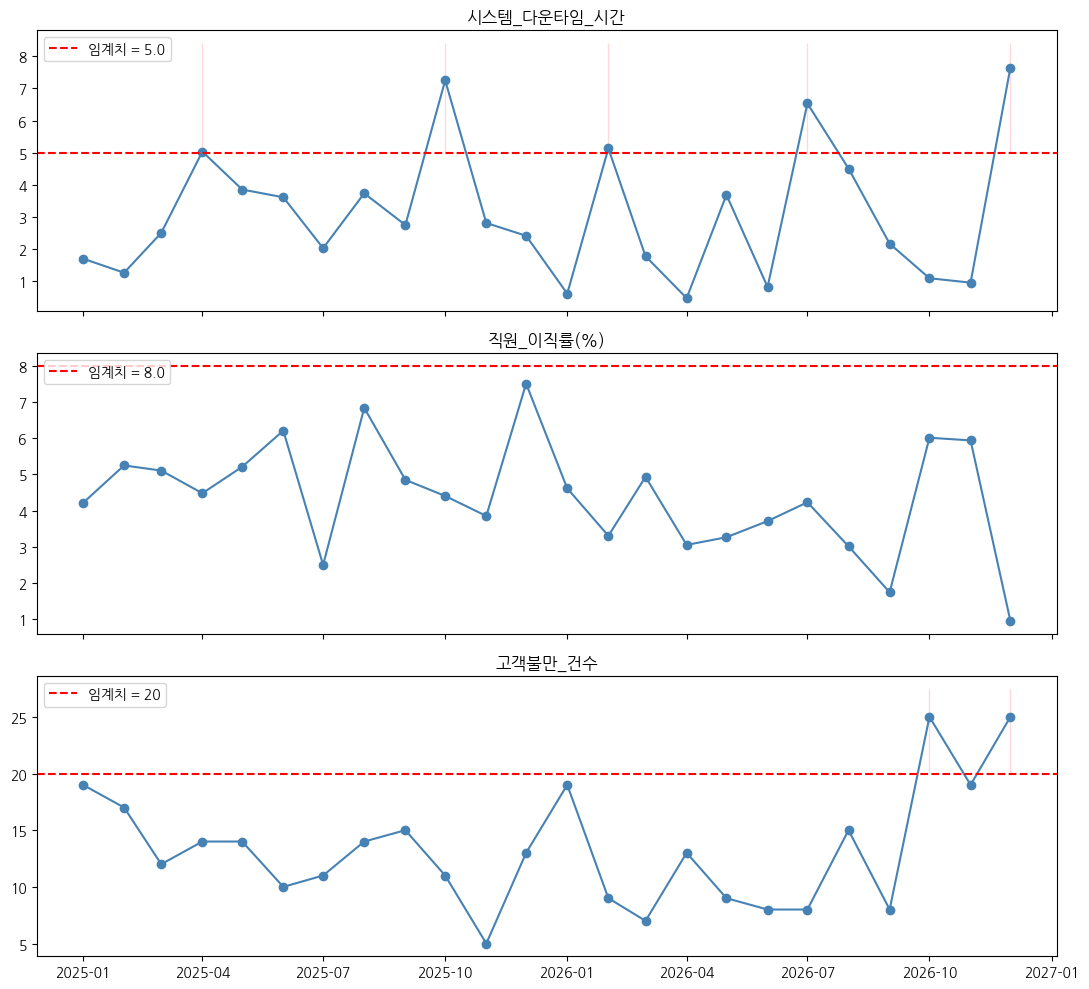

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

for ax, (kri, limit) in zip(axes, thresholds.items()):
    ax.plot(kri_data['month'], kri_data[kri], marker='o', color='steelblue')
    ax.axhline(limit, color='red', linestyle='--', label=f'임계치 = {limit}')
    ax.fill_between(kri_data['month'], limit, kri_data[kri].max()*1.1,
                     where=(kri_data[kri] > limit), color='red', alpha=0.15)
    ax.set_title(kri)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

각 KRI를 시계열 그래프로 그리고, 빨간 점선(임계치)을 초과한 구간은 붉게 음영 처리. 한눈에 "어떤 지표가 최근 악화되고 있는지" 파악 가능.